In [383]:
#loading in my dataset + checking its structure
import json
import networkx as nx

__path__ = r"C:\Users\lars_\MBDM\Week 3 - Dynamics on Networks\Datasets\congress_network\congress_network_data.json"

with open(__path__, "r", encoding="utf-8") as df:
    raw = json.load(df)

# extracting the data from the raw list that is loaded from the json file
adj_list = raw[0]["inList"]

print(type(adj_list))
print(len(adj_list))           # number of nodes
print(adj_list[0][:10])        # first ten neighbors ofnode 0

<class 'list'>
475
[4, 9, 11, 13, 18, 27, 29, 33, 38, 45]


In [384]:
#made the network directed since that is more useful for assignement 2
#why: influcence is mutual, not directed.
G = nx.Graph()

for node, neighbors in enumerate(adj_list):
    for nb in neighbors:
        G.add_edge(node, nb)

Start of Running through notebook


In [385]:
#loading the libraries
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import random
from time import time

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = False
plt.rcParams['figure.dpi'] = 120

print("Packages loaded.")

Packages loaded.


In [386]:
# Parameters
N = G.number_of_nodes()  # Number of nodes in the network
#k_avg = 6 #dont think this is used
B = int(0.02 * N) #10% of 
ENSEMBLES = 10 # Number of ensemble simulations to run
RUNS_PER_SETTING = 15 # Number of simulation runs for each threshold setting

# Threshold mode, defines how the threshold is set for each node
THRESHOLD_MODE = 'beta'   # 'uniform', 'beta', 'constant', 'normal'
PHI_MEAN = 0.30
PHI_STD = 0.10

# Maximum number of steps in each simulation run
MAX_STEPS = 200
# Number of steps to run the greedy algorithm for
#GREEDY_R = 5

print(f"N={N}, B={B}, ENSEMBLES={ENSEMBLES}, RUNS_PER_SETTING={RUNS_PER_SETTING}")


N=475, B=9, ENSEMBLES=10, RUNS_PER_SETTING=15


In [387]:
import networkx as nx

def create_network_from_adj_list(adj_list):
    """
    Maak een undirected netwerk (Graph) van een adjacentielijst.

    Args:
        adj_list (list of lists): Een lijst waar het indexnummer de knoop (node)
                                  vertegenwoordigt en de waarde een lijst is van
                                  zijn buren (neighbors). Dit is de structuur van `raw[0]["inList"]`.

    Returns:
        networkx.Graph: Een ongerichte graaf van de Twitter/Congress verbindingen.
    """
    print("Creating network from adjacency list...")

    # We gebruiken from_dict_of_lists om de adjacentielijst te converteren naar een graaf.
    # Eerst moeten we de lijst converteren naar een dictionary, waarbij de index
    # de knoop-ID is.
    
    # Maak een dictionary {node_id: [neighbor1, neighbor2, ...]}
    # waarbij node_id de index is van de adj_list
    adj_dict = {i: neighbors for i, neighbors in enumerate(adj_list)}
    
    # Maak de graaf, beginnend als een Directed Graph (DiGraph)
    # Dit behoudt alle links, inclusief de ongerichte links
    G_directed = nx.from_dict_of_lists(adj_dict, create_using=nx.DiGraph)

    # Converteer naar een ongerichte graaf (Graph)
    # Door naar een Graph te converteren, worden dubbele verbindingen (u->v en v->u)
    # automatisch behandeld als één ongerichte verbinding {u, v}.
    # Dit is de snelste manier om een ongerichte graaf uit jouw data te maken.
    G = G_directed.to_undirected()

      # --- Hier pakken we de largest connected component ---
    if not nx.is_connected(G):
        largest_cc_nodes = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_cc_nodes).copy()
        print(f"Largest connected component selected: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

    else:
        print("Network is already connected")

    print(f"Network created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
    
    return G

# --- Hoe je de functie gebruikt met je geladen data ---

# Stel dat je 'adj_list' al hebt geladen:
# adj_list = raw[0]["inList"]

# Voorbeeld met de bestaande code:
# G_congress = create_network_from_adj_list(adj_list)
# print(G_congress)

In [388]:
# This function builds three different types of networks: Erdős-Rényi (ER), Watts-Strogatz (WS), and Barabási-Albert (BA)
# Each network is generated with a specified number of nodes (N) and average degree (k_avg)
# The seed_base parameter is used to ensure different random networks are generated each time the function is called
def build_networks(N, k_avg, seed_base=0):
    
    G = create_network_from_adj_list(adj_list)
   
    return {'Real': G}

graphs = build_networks(N, k_avg, seed_base=RANDOM_SEED)
{name: (G.number_of_nodes(), G.number_of_edges()) for name, G in graphs.items()}    

Creating network from adjacency list...
Network is already connected
Network created with 475 nodes and 10222 edges


{'Real': (475, 10222)}

In [389]:
# Create real graph from adjacency list
G = create_network_from_adj_list(adj_list)

print("REAL graph loaded")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Creating network from adjacency list...
Network is already connected
Network created with 475 nodes and 10222 edges
REAL graph loaded
Nodes: 475
Edges: 10222


In [390]:
# This function draws threshold values for each node in the graph G
# The threshold mode determines how the threshold values are generated
# Each node samples a threshold value from a specified distribution (defined by mode)
# The phi_mean and phi_std parameters are used to control the mean and standard deviation of the normal distribution
def draw_thresholds(G, mode='uniform', phi_mean=0.3, phi_std=0.1):
    if mode == 'uniform':
        return {n: np.random.uniform(0, 1) for n in G}
    if mode == 'beta':
        a, b = 3, 7
        return {n: np.random.beta(a, b) for n in G}
    if mode == 'constant':
        return {n: float(phi_mean) for n in G}
    if mode == 'normal':
        vals = np.clip(np.random.normal(phi_mean, phi_std, len(G)), 0, 1)
        return {n: float(vals[i]) for i, n in enumerate(G)}
    raise ValueError(f"Unknown threshold mode: {mode}")

# This loop iterates over each graph in the graphs dictionary
# For each graph, it draws threshold values using the draw_thresholds function
# It then calculates the mean of these threshold values and prints it
for name, G in graphs.items():
    th = draw_thresholds(G, mode=THRESHOLD_MODE, phi_mean=PHI_MEAN, phi_std=PHI_STD)
    arr = np.array(list(th.values()))
    print(name, "threshold mean:", round(arr.mean(), 3))

Real threshold mean: 0.297


In [391]:
# This function simulates the threshold dynamics on a graph G
# The function takes as input the graph G, a list of seed nodes (seeds), a dictionary of threshold values (thresholds), and the maximum number of steps (max_steps)
# The function returns a dictionary of adopted nodes (adopted) and a numpy array of the fraction of adopted nodes over time (history)
def threshold_dynamics(G, seeds, thresholds, max_steps=100):
    adopted = {n: 0 for n in G}
    for s in seeds:
        adopted[s] = 1 # initially, all seed nodes are adopted

    history = [sum(adopted.values()) / len(G)] #the history will store the fraction of adopted nodes over time, initially it is the fraction of adopted seed nodes

    for _ in range(max_steps): # iterate max_steps times
        new_adopted = adopted.copy()
        changed = False
        for i in G: # iterate over all nodes i in the graph G
            if adopted[i] == 0: # if node i is not adopted yet
                neigh = list(G.neighbors(i))
                if not neigh: # if node i has no neighbors, skip it
                    continue
                frac = sum(adopted[j] for j in neigh) / len(neigh) # calculate the fraction of adopted neighbors of node i
                if frac >= thresholds[i]: # if the fraction of adopted neighbors is greater than or equal to the threshold of node i
                    new_adopted[i] = 1 # adopt node i
                    changed = True
        #-- end of one iteration

        # update the adopted nodes after checking all nodes
        adopted = new_adopted
        history.append(sum(adopted.values()) / len(G)) #add the total adopted this timestep to the history
        if not changed:
            break # if no node is adopted in this iteration, break the loop (no more adoptions so we can stop)

    return adopted, np.array(history)

In [392]:
def final_adoption_fraction(adopted):
    return sum(adopted.values()) / len(adopted)

# function to calculate the time to reach a target fraction of adopted nodes
def time_to_fraction(history, target=0.5):
    idx = np.where(history >= target)[0]
    return float(idx[0]) if len(idx) else np.nan


In [393]:
def random_seeds(G, B):
    return random.sample(list(G.nodes()), B)

def high_degree_seeds(G, B):
    """
    Select the top-B nodes with the highest degree in graph G.
    """
    # Get all (node, degree) pairs
    degree_list = list(G.degree())

    # Sort nodes by degree in descending order
    sorted_by_degree = sorted(degree_list, key=lambda x: x[1], reverse=True)

    # Take the top-B entries
    top_B = sorted_by_degree[:B]

    # Extract only the node IDs
    result = []
    for n, d in top_B:
        result.append(n)

    return result


#This code below does the same as for degree. It uses a list comprehension and a lambda function.
# The lambda function takes a tuple x = (n, b) and returns the second element (b), which is the betweenness centrality of node n.]
# sorted(bc.items(), key=lambda x: x[1], reverse=True) sorts the items of the dictionary bc.items() by the value of the betweenness centrality (x[1]) in descending order. (Highest first)
# [:B] takes the first B entries from the sorted list, which are the nodes with the highest betweenness centrality.
def betweenness_seeds(G, B):
    bc = nx.betweenness_centrality(G) #returns a dictionary that maps each node to its betweenness centrality. {n_1: bc(n_1), n_2: bc(n_2), ...}
    return [n for n, _ in sorted(bc.items(), key=lambda x: x[1], reverse=True)[:B]]


# This function seeds the network with B nodes with the highest core number, the core number is the number of nodes that are connected to all its neighbors
# For a given graph G, the core number of a node v is the largest integer k such that v belongs to the k-core of G.
# In other words:
# 	•	It tells you how deeply embedded a node is within the dense core structure of the network.
# 	•	A higher core number means the node is part of a more cohesive and connected region of the graph.
def kcore_seeds(G, B):
    core = nx.core_number(G) #core_number is a dictionary that maps each node to its core number. 
    return [n for n, _ in sorted(core.items(), key=lambda x: x[1], reverse=True)[:B]]

In [394]:
# This function estimates the spread of the threshold dynamics on graph G
# It runs the threshold dynamics R times with different random seeds and thresholds
# and returns the average final adoption fraction
def estimate_spread(G, seeds, thresholds, R=5, max_steps=100):
    results = []
    for _ in range(R):
        adopted, _ = threshold_dynamics(G, seeds, thresholds, max_steps=max_steps)
        results.append(final_adoption_fraction(adopted))
    return float(np.mean(results))


In [395]:
def run_experiments_corrected(G_real=G, ensembles=10, runs_per_setting=15, threshold_mode='uniform',
                              phi_mean=0.3, phi_std=0.1, B=5, max_steps=200):
    
    # Importeer alle benodigde functies en modules
    import numpy as _np
    import pandas as _pd
    import random
    from time import time as _time
    
    # Gebruik de globale functies (draw_thresholds, high_degree_seeds, etc.)
    # om de code leesbaar te houden
    
    results = []
    t0 = _time()
    
    # Het 'Real' netwerk is slechts één graaf en moet niet E keer opnieuw worden geladen.
    # We simuleren de ensemble-runs direct op G_real.
    name = 'Real'
    G = G_real

    # De seed-sets (Degree, K-core, Betweenness) hangen alleen af van G, niet van de runs/ensembles
    strategies = {
        'Random': lambda: random_seeds(G, B), # Random wordt in elke run willekeurig getrokken
        'Degree': lambda: high_degree_seeds(G, B),
        'K-core': lambda: kcore_seeds(G, B),
        'Betweenness': lambda: betweenness_seeds(G, B),
    }

    # Ensemble-loop voor het middelen over willekeurigheid (van drempels en willekeurige seeds)
    for e in range(ensembles):
        for strat, seed_fn in strategies.items():
            
            # 1. Seeds bepalen:
            # Voor Random is de seed_fn() telkens een nieuwe willekeurige set,
            # voor de andere is het een constante set.
            seeds = seed_fn()
            
            final_sizes, t50_list = [], []
            
            # Runs-per-setting loop: simuleer de diffusie R keer voor middeling
            for r in range(runs_per_setting):
                
                # CRUCIALE CORRECTIE: Trek de drempelwaarden HIER voor elke run
                # Dit zorgt ervoor dat de drempelwaarden (tenzij 'constant')
                # willekeurig zijn in elke runs_per_setting.
                thresholds = draw_thresholds(G, mode=threshold_mode, phi_mean=phi_mean, phi_std=phi_std)
                
                # CRUCIALE CORRECTIE: Voor de 'Random' strategie moet je de seeds hier opnieuw trekken
                # om te middelen over verschillende willekeurige seed-sets.
                # Als de strategie 'Random' is, trek dan de seeds hier opnieuw
                if strat == 'Random':
                    seeds = seed_fn()
                    
                adopted, history = threshold_dynamics(G, seeds, thresholds, max_steps=max_steps)
                
                final_sizes.append(final_adoption_fraction(adopted))
                t50_list.append(time_to_fraction(history, target=0.5))

            # Na runs_per_setting runs, bereken de gemiddelden en sla op
            results.append({
                'Ensemble': e,
                'Network': name,
                'Strategy': strat,
                'FinalAdoption': float(_np.mean(final_sizes)),
                'CascadeProb': float(_np.mean(_np.array(final_sizes) >= 0.5)),
                'Time50': float(_np.nanmean(t50_list)),
                'Efficiency': float(_np.mean(final_sizes) / B),
                'Seeds': seeds # Let op: dit is de laatste seed set, niet de gemiddelde
            })
            
    t1 = _time()
    print(f"Completed {ensembles} ensembles x 1 netwerk x {len(strategies)} strategies in {t1 - t0:.1f}s")
    return _pd.DataFrame(results)

In [396]:
df_results = run_experiments_corrected(
    G_real=G,
    ensembles=ENSEMBLES,
    runs_per_setting=RUNS_PER_SETTING,
    threshold_mode=THRESHOLD_MODE,
    phi_mean=PHI_MEAN,
    phi_std=PHI_STD,
    B=B,
    max_steps=MAX_STEPS,
    #greedy_R=GREEDY_R
)
df_results.head()

C:\Users\lars_\AppData\Local\Temp\ipykernel_20184\158569533.py:66: RuntimeWarning: Mean of empty slice
  'Time50': float(_np.nanmean(t50_list)),


Completed 10 ensembles x 1 netwerk x 4 strategies in 18.4s


,Ensemble,Network,Strategy,FinalAdoption,CascadeProb,Time50,Efficiency,Seeds
0,0,Real,Random,0.023018,0.0,NaN,0.002558,"[108, 467, 290, 448, 367, 161, 335, 255, 202]"
1,0,Real,Degree,1.000000,1.0,6.266667,0.111111,"[367, 322, 254, 208, 393, 190, 111, 192, 269]"
2,0,Real,K-core,0.028912,0.0,NaN,0.003212,"[71, 87, 92, 95, 101, 102, 103, 105, 107]"
3,0,Real,Betweenness,1.000000,1.0,7.600000,0.111111,"[367, 322, 254, 208, 17, 71, 393, 461, 92]"
4,1,Real,Random,0.025263,0.0,NaN,0.002807,"[332, 191, 224, 460, 264, 231, 61, 126, 115]"


In [397]:
pivot_final = df_results.pivot_table(index='Strategy', columns='Network', values='FinalAdoption', aggfunc='mean')
pivot_cascade = df_results.pivot_table(index='Strategy', columns='Network', values='CascadeProb', aggfunc='mean')
pivot_eff = df_results.pivot_table(index='Strategy', columns='Network', values='Efficiency', aggfunc='mean')

print("Final adoption (mean):")
display(pivot_final)
print("\nCascade probability (mean):")
display(pivot_cascade)
print("\nEfficiency (mean):")
display(pivot_eff)

Final adoption (mean):


Network,Real
Strategy,
Betweenness,0.975060
Degree,1.000000
K-core,0.123495
Random,0.030147



Cascade probability (mean):


Network,Real
Strategy,
Betweenness,0.973333
Degree,1.000000
K-core,0.093333
Random,0.006667



Efficiency (mean):


Network,Real
Strategy,
Betweenness,0.108340
Degree,0.111111
K-core,0.013722
Random,0.003350


<Figure size 840x480 with 0 Axes>

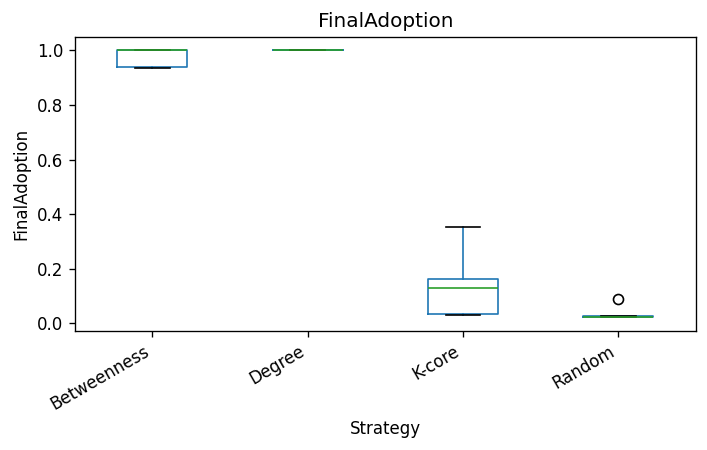

<Figure size 840x480 with 0 Axes>

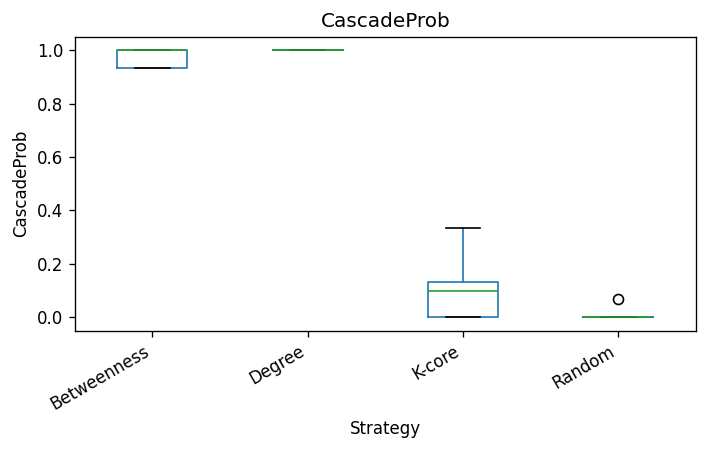

<Figure size 840x480 with 0 Axes>

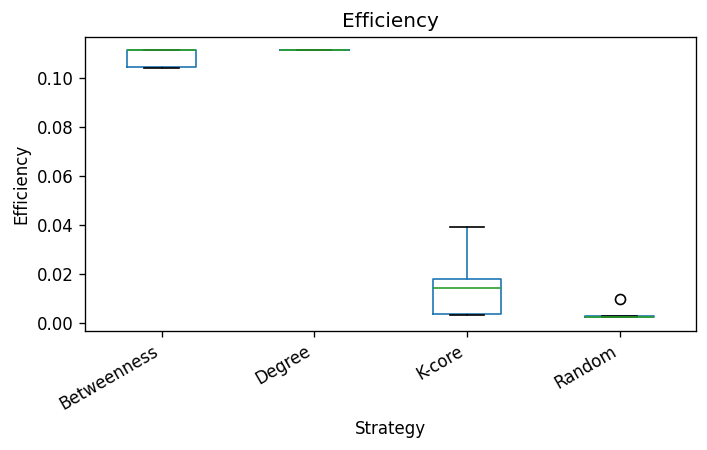

In [398]:
# Separate charts per metric, no seaborn and no explicit colors
metrics = ['FinalAdoption', 'CascadeProb', 'Efficiency']
for metric in metrics:
    plt.figure(figsize=(7,4))
    df_results.boxplot(column=metric, by='Strategy', grid=False)
    plt.title(metric)
    plt.suptitle("")
    plt.xlabel("Strategy")
    plt.ylabel(metric)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

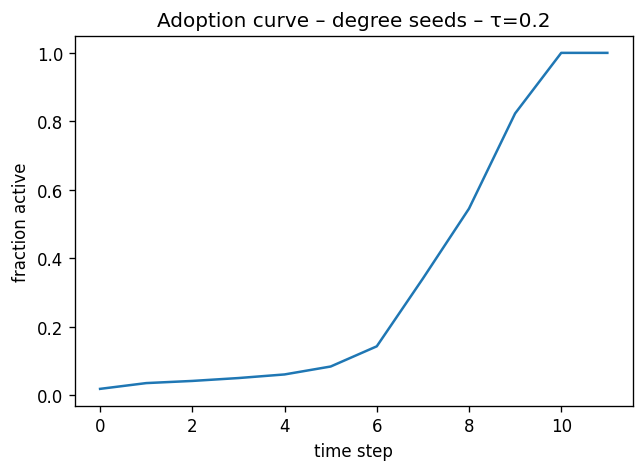

In [399]:
seeds = high_degree_seeds(G, B)
thresholds = draw_thresholds(G, mode='constant', phi_mean=0.2)

adopted, history = threshold_dynamics(G, seeds, thresholds)

plt.plot(history)
plt.xlabel("time step")
plt.ylabel("fraction active")
plt.title("Adoption curve – degree seeds – τ=0.2")
plt.show()

In [400]:
# --- SANITY CHECK ---
print("Nodes, Edges in G:", G.number_of_nodes(), G.number_of_edges())
N = G.number_of_nodes()

# huidige B instellen (zoals jouw notebook)
B = int(0.02 * N)   # pas aan als je wilt testen
print("Using B =", B, f"({100*B/N:.1f}% of N)")

mean_degree = sum(dict(G.degree()).values()) / N
print("Average degree:", round(mean_degree, 2))
print("Approx. required active neighbors for tau=0.2:", int(np.ceil(0.2 * mean_degree)))
print("Approx. required active neighbors for tau=0.3:", int(np.ceil(0.3 * mean_degree)))

Nodes, Edges in G: 475 10222
Using B = 9 (1.9% of N)
Average degree: 43.04
Approx. required active neighbors for tau=0.2: 9
Approx. required active neighbors for tau=0.3: 13


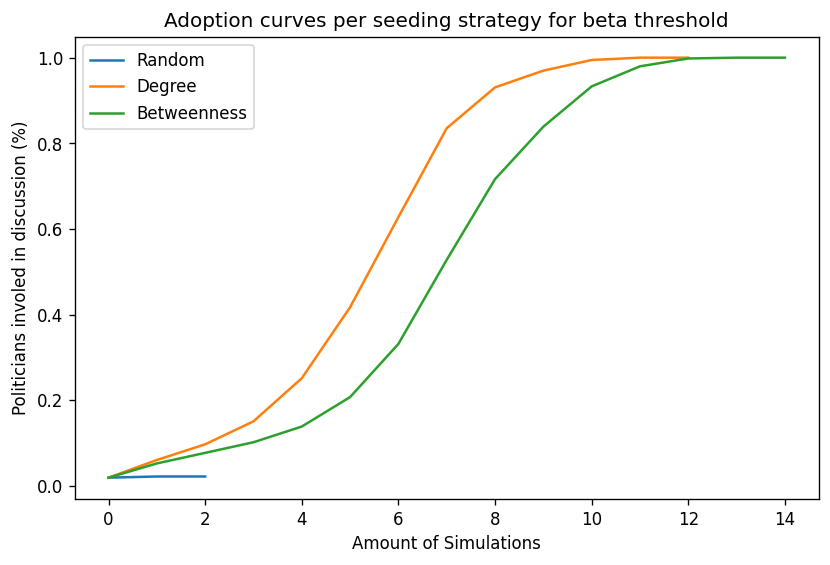

In [401]:
import matplotlib.pyplot as plt
import numpy as np

strategies = {
    'Random': lambda G: random_seeds(G, B),
    'Degree': lambda G: high_degree_seeds(G, B),
    #'K-core': lambda G: kcore_seeds(G, B),
    'Betweenness': lambda G: betweenness_seeds(G, B)
}

plt.figure(figsize=(8,5))

for strat_name, seed_fn in strategies.items():
    histories = []
    for e in range(ENSEMBLES):
        seeds = seed_fn(G)  # bepaal seeds per ensemble
        thresholds = draw_thresholds(G, mode=THRESHOLD_MODE, phi_mean=PHI_MEAN, phi_std=PHI_STD)
        _, history = threshold_dynamics(G, seeds, thresholds, max_steps=MAX_STEPS)
        histories.append(history)
    
    # Gemiddelde over ensembles
    max_len = max(len(h) for h in histories)
    # pad shorter histories met laatste waarde
    histories_padded = [np.pad(h, (0, max_len - len(h)), 'edge') for h in histories]
    hist_avg = np.mean(histories_padded, axis=0)
    
    plt.plot(hist_avg, label=strat_name)

plt.xlabel('Amount of Simulations')
plt.ylabel('Politicians involed in discussion (%)')
plt.title('Adoption curves per seeding strategy for beta threshold')
plt.legend()
plt.show()


In [359]:
# Uniform
#THRESHOLD_MODE = 'uniform'
#df_uniform = run_experiments_corrected(G, ensembles=ENSEMBLES, runs_per_setting=RUNS_PER_SETTING,
                                       #threshold_mode=THRESHOLD_MODE, phi_mean=PHI_MEAN, phi_std=PHI_STD,
                                       #B=B, max_steps=MAX_STEPS)

# Beta
#THRESHOLD_MODE = 'beta'
#df_beta = run_experiments_corrected(G, ensembles=ENSEMBLES, runs_per_setting=RUNS_PER_SETTING,
                                    #threshold_mode=THRESHOLD_MODE, phi_mean=PHI_MEAN, phi_std=PHI_STD,
                                    #B=B, max_steps=MAX_STEPS)

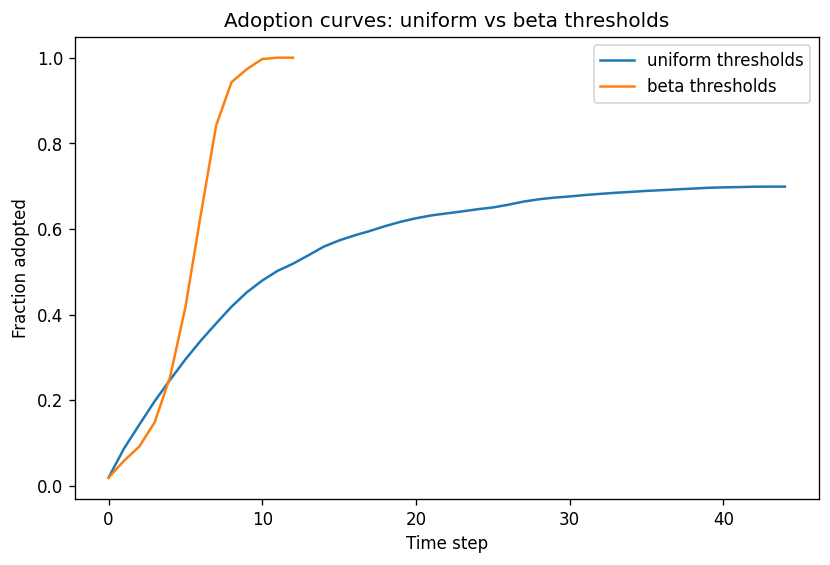

In [360]:
import matplotlib.pyplot as plt
import numpy as np

# Kies strategieën die je wilt vergelijken
strategies = {
    'Degree': lambda G: high_degree_seeds(G, B)
}

# Drempelmodi om te vergelijken
threshold_modes = ['uniform', 'beta']    

plt.figure(figsize=(8,5))

for mode in threshold_modes:
    histories = []
    for e in range(ENSEMBLES):
        seeds = high_degree_seeds(G, B)  # dezelfde seeds voor eerlijke vergelijking
        thresholds = draw_thresholds(G, mode=mode, phi_mean=PHI_MEAN, phi_std=PHI_STD)
        _, history = threshold_dynamics(G, seeds, thresholds, max_steps=MAX_STEPS)
        histories.append(history)
    
    # Gemiddelde over ensembles
    max_len = max(len(h) for h in histories)
    histories_padded = [np.pad(h, (0, max_len - len(h)), 'edge') for h in histories]
    hist_avg = np.mean(histories_padded, axis=0)
    
    plt.plot(hist_avg, label=f"{mode} thresholds")

plt.xlabel('Time step')
plt.ylabel('Fraction adopted')
plt.title('Adoption curves: uniform vs beta thresholds')
plt.legend()
plt.show()

In [380]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx 
# Importeer de benodigde functies uit je eerdere code

# --- CONSTANTEN ---
N_SEEDS = 9
RUNS = 150
FIXED_TAU = 0.2
STRATEGIES_TO_PLOT = ['Degree', 'Betweenness', 'Random']
LINE_STYLES = {'Degree': 'tab:orange', 'Betweenness': 'tab:red', 'Random': 'tab:blue'}

# --- FUNCTIE VOOR GEMIDDELDE CURVE ---

def get_average_history(G, strategy, fixed_tau, runs=RUNS):
    """
    Voert de simulatie runs uit en berekent de gemiddelde adoptie (history) per tijdstap.
    """
    all_histories = []
    
    # Run de simulatie 150 keer
    for _ in range(runs):
        seeds = get_seeds(G, strategy, k=N_SEEDS)
        
        # Trek drempels: Hier is de mode 'constant'
        thresholds = draw_thresholds(G, mode='constant', params=fixed_tau)
        
        # history bevat de fractie adoptie per tijdstap
        # De functie threshold_dynamics moet hier een lijst/array met de volledige geschiedenis retourneren.
        # (Aanname: je hebt je threshold_dynamics functie aangepast om de volledige 'history' array te retourneren)
        _, history_data = threshold_dynamics(G, seeds, thresholds)
        
        all_histories.append(history_data)

    # Vind de maximale lengte van de runs (voor padding)
    max_len = max(len(h) for h in all_histories)
    
    # Pad kortere runs op met hun eindwaarde om het middelen mogelijk te maken
    padded_histories = []
    for h in all_histories:
        last_val = h[-1]
        padded = np.pad(h, (0, max_len - len(h)), mode='constant', constant_values=last_val)
        padded_histories.append(padded)
        
    # Bereken de gemiddelde adoptie voor elke tijdstap
    avg_history = np.mean(padded_histories, axis=0)
    return avg_history

# --- HOOFDPROGRAMMA VOOR PLOTTEN ---

if __name__ == '__main__':
    
    # 1. Laad Graaf (BELANGRIJK: zorg dat deze functie correct werkt)
    G = load_graph() 
    print(f"Netwerk geladen met N={G.number_of_nodes()} knopen.")
    
    plt.figure(figsize=(10, 6))
    
    # 2. Loop door de strategieën en plot de gemiddelde curve
    for strategy in STRATEGIES_TO_PLOT:
        print(f"  > Berekenen gemiddelde curve voor: {strategy}")
        
        # Roep de nieuwe middelfunctie aan
        avg_history_data = get_average_history(G, strategy, FIXED_TAU, runs=RUNS)
        
        # Plot de gemiddele curve
        plt.plot(
            avg_history_data, 
            label=f"{strategy} (Avg. {RUNS} runs)",
            color=LINE_STYLES[strategy]
        )

    # 3. Finaliseer de plot
    plt.xlabel("Time step")
    plt.ylabel("Fraction adopted")
    plt.title(f"Average Adoption Curves ($\tau$ = {FIXED_TAU})")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

NameError: name 'load_graph' is not defined